# Prueba técnica Sudata
Autor: Patricio García <br>
Correo: patricionerigacia@gmail.com

### Video explicativo

Incluyo un breve video explicando el enfoque general de la solución, las principales decisiones tomadas y cómo ejecutar la entrega:

[Ver video explicativo](PEGAR_LINK_ACÁ)

## Parte 1 - Limpieza de datos
En esta sección se realiza la carga de los dataset, la limpieza de datos y tratamientos de valores nulo, la combinación de los datasets y finalmente el exportación de un solo dataset.



### Librerias

In [451]:
# Importa librerías
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

### Lectura y análisis

In [452]:
# Lee Datasets
a = pd.read_csv("../data/listings_plataforma_A.csv")
b = pd.read_csv("../data/listings_plataforma_B.csv")
c = pd.read_csv("../data/listings_plataforma_C.csv")


In [453]:
# Inspecciona datasets
def explore_df(df, name):
    print(f"\n{'='*50}")
    print(f"DATASET: {name}")
    print(f"{'='*50}")
    
    print("\n🔹 Shape (filas, columnas):")
    print(df.shape)
    
    print("\n🔹 Columnas:")
    print(df.columns.tolist())
    
    print("\n🔹 Head:")
    display(df.head())
    
    print("\n🔹 Missing values por columna:")
    display(df.isna().sum().sort_values(ascending=False))
    
    print("\n🔹 % Missing:")
    display((df.isna().mean()*100).sort_values(ascending=False))

In [454]:
explore_df(a, "listings_plataforma_A")


DATASET: listings_plataforma_A

🔹 Shape (filas, columnas):
(3662, 18)

🔹 Columnas:
['id_aviso', 'titulo', 'zona_barrio', 'tipo', 'precio', 'expensas', 'superficie_total', 'superficie_cubierta', 'ambientes', 'dormitorios', 'banios', 'antiguedad', 'cochera', 'balcon', 'amenities', 'latitud', 'longitud', 'fecha_publicacion']

🔹 Head:


,id_aviso,titulo,zona_barrio,tipo,precio,expensas,superficie_total,superficie_cubierta,ambientes,dormitorios,banios,antiguedad,cochera,balcon,amenities,latitud,longitud,fecha_publicacion
0,A-700480,Departamento en alquiler en Belgrano - 4 ambie...,BELGRANO,Departamento,1.267.000,140298.0,75,75.0,4 amb.,3.0,2.0,4 años,Sí,Sí,NaN,-34.549646421652646,-58.462834001141694,04/01/2025
1,A-220016,Departamento en alquiler en Almagro - 2 ambientes,Almagro,Departamento,584.000,77822.0,39,NaN,2 amb.,1.0,NaN,6,No,No,NaN,-34.60873815826056,-58.43909947532191,15/01/2024
2,A-492142,Departamento en alquiler en Flores - 2 ambientes,Flores,Departamento,252.000,NaN,35 m²,35.0,2,NaN,1.0,23,Sí,No,NaN,"-34,62205081312381",-58.45626733855754,07/03/2024
3,A-675147,PH en alquiler en Belgrano - 2 ambientes,Belgrano,PH,546.000,NaN,38 m²,38.0,2 amb.,1.0,1.0,A estrenar,No,No,Pileta,-34.574756771995716,-58.463757544997684,04/12/2024
4,A-307536,Departamento en alquiler en Villa Urquiza - 1 ...,Villa Urquiza,Departamento,337.000,52942.0,33 m²,NaN,1,NaN,1.0,2,No,Sí,NaN,-34.55428879305003,-58.4866156408398,25/02/2024



🔹 Missing values por columna:


amenities              3326
expensas               1672
superficie_cubierta     510
dormitorios             364
antiguedad              320
banios                  279
titulo                    0
id_aviso                  0
precio                    0
zona_barrio               0
ambientes                 0
superficie_total          0
tipo                      0
cochera                   0
balcon                    0
latitud                   0
longitud                  0
fecha_publicacion         0
dtype: int64


🔹 % Missing:


amenities              90.824686
expensas               45.658110
superficie_cubierta    13.926816
dormitorios             9.939924
antiguedad              8.738394
banios                  7.618788
titulo                  0.000000
id_aviso                0.000000
precio                  0.000000
zona_barrio             0.000000
ambientes               0.000000
superficie_total        0.000000
tipo                    0.000000
cochera                 0.000000
balcon                  0.000000
latitud                 0.000000
longitud                0.000000
fecha_publicacion       0.000000
dtype: float64

In [455]:
explore_df(b, "listings_plataforma_B")


DATASET: listings_plataforma_B

🔹 Shape (filas, columnas):
(3639, 18)

🔹 Columnas:
['listing_id', 'category_l1', 'category_l2', 'property_type', 'neighborhood', 'price_ars', 'covered_area_m2', 'total_area_m2', 'rooms', 'bedrooms', 'bathrooms', 'age_years', 'has_garage', 'has_balcony', 'has_pool', 'lat', 'lng', 'created_at']

🔹 Head:


,listing_id,category_l1,category_l2,property_type,neighborhood,price_ars,covered_area_m2,total_area_m2,rooms,bedrooms,bathrooms,age_years,has_garage,has_balcony,has_pool,lat,lng,created_at
0,MLA757902287,Inmuebles,Alquiler,DEPARTAMENTO,Palermo,713000.0,50.0,50.0,NaN,2.0,1.0,14.0,False,True,False,-34.549232,-58.425510,2025-01-18 00:00:00
1,MLA371511639,Inmuebles,Alquiler,DEPARTAMENTO,Almagro,724000.0,50.0,50.0,2.0,1.0,1.0,NaN,False,False,False,-34.586467,-58.439921,2024-08-08 00:00:00
2,MLA154908801,Inmuebles,Alquiler,DEPARTAMENTO,Almagro,348000.0,42.0,NaN,2.0,NaN,1.0,13.0,True,False,False,-34.607493,-58.417589,2024-08-18 00:00:00
3,MLA403100436,Inmuebles,Alquiler,DEPARTAMENTO,Villa Urquiza,1217000.0,66.0,66.0,2.0,1.0,1.0,2.0,True,True,False,-34.567514,-58.487023,2024-11-03 00:00:00
4,MLA346000441,Inmuebles,Alquiler,CASA,Palermo,1121000.0,86.0,164.0,3.0,2.0,1.0,1.0,True,False,True,-34.589963,-58.444575,2025-03-22 00:00:00



🔹 Missing values por columna:


age_years          1071
total_area_m2       700
price_ars           213
covered_area_m2     187
bathrooms           142
rooms               138
bedrooms            116
listing_id            0
category_l1           0
neighborhood          0
property_type         0
category_l2           0
has_garage            0
has_balcony           0
has_pool              0
lat                   0
lng                   0
created_at            0
dtype: int64


🔹 % Missing:


age_years          29.431162
total_area_m2      19.236054
price_ars           5.853256
covered_area_m2     5.138774
bathrooms           3.902171
rooms               3.792251
bedrooms            3.187689
listing_id          0.000000
category_l1         0.000000
neighborhood        0.000000
property_type       0.000000
category_l2         0.000000
has_garage          0.000000
has_balcony         0.000000
has_pool            0.000000
lat                 0.000000
lng                 0.000000
created_at          0.000000
dtype: float64

In [456]:
explore_df(c, "listings_plataforma_C")


DATASET: listings_plataforma_C

🔹 Shape (filas, columnas):
(3699, 9)

🔹 Columnas:
['codigo', 'operacion', 'tipo_inmueble', 'barrio', 'precio_publicado', 'superficie', 'descripcion', 'coordenadas', 'publicado']

🔹 Head:


,codigo,operacion,tipo_inmueble,barrio,precio_publicado,superficie,descripcion,coordenadas,publicado
0,AP-64391,Alquiler,ph,Villa Urquiza,$678.000/mes,55,2 ambientes. 1 dorm. 1 baños. pileta,"-34.57599599633878,-58.47863988110282",10-03-2024
1,AP-82260,Alquiler,ph,Colegiales,$700.000/mes,50,2 ambientes. 1 dorm. 1 baños. balcón. 11 años,"-34.582690398643514,-58.4524965859866",30-11-2024
2,AP-66765,Alquiler,departamento,Caballito,$719.000/mes,41,3 ambientes. 2 baños. 11 años,NaN,28-07-2024
3,AP-42570,Alquiler,departamento,Villa Crespo,$1.391.000/mes,58,3 ambientes. 2 dorm. con cochera. 4 años,NaN,31-12-2024
4,AP-64652,Alquiler,departamento,Recoleta,Consultar,53,3 ambientes. 2 dorm. 2 baños. con cochera. 18 ...,NaN,08-01-2025



🔹 Missing values por columna:


coordenadas         1464
superficie           186
descripcion           17
codigo                 0
operacion              0
precio_publicado       0
barrio                 0
tipo_inmueble          0
publicado              0
dtype: int64


🔹 % Missing:


coordenadas         39.578264
superficie           5.028386
descripcion          0.459584
codigo               0.000000
operacion            0.000000
precio_publicado     0.000000
barrio               0.000000
tipo_inmueble        0.000000
publicado            0.000000
dtype: float64

### Definición de schema y alcance de los datos

Para la construcción del dataset unificado se definió el siguiente schema target, priorizando variables relevantes para la estimación de precios y que estén disponibles (o sean inferibles) en la mayoría de las fuentes:

schema = [
    "source",
    "price",
    "currency",
    "total_area_m2",
    "covered_area_m2",
    "rooms",
    "bedrooms",
    "bathrooms",
    "property_type",
    "neighborhood",
    "lat",
    "lon",
    "description"
]

Este schema prioriza variables relevantes para pricing y consistentes entre fuentes, buscando un balance entre completitud y robustez.
Se decidió excluir la plataforma C en esta instancia por su baja estructuración y alta dependencia de texto libre, priorizando datasets más limpios dado el tiempo acotado de la prueba.
En un contexto real, esta fuente sería aprovechada mediante extracción de información desde la descripción (NLP/regex) para enriquecer el dataset y aumentar el volumen de datos disponibles.

In [457]:
a_clean = a.copy()

# Renombra columnas
a_clean = a_clean.rename(columns={
    "precio": "price",
    "superficie_total": "total_area_m2",
    "superficie_cubierta": "covered_area_m2",
    "ambientes": "rooms",
    "dormitorios": "bedrooms",
    "banios": "bathrooms",
    "tipo": "property_type",
    "zona_barrio": "neighborhood",
    "latitud": "lat",
    "longitud": "lon"
})

# Agregar columnas faltantes
a_clean["currency"] = None 
a_clean["description"] = None
a_clean["source"] = "A"

# Selecciona columnas del schema
a_clean = a_clean[[
    "source", "price", "currency",
    "total_area_m2", "covered_area_m2",
    "rooms", "bedrooms", "bathrooms",
    "property_type", "neighborhood",
    "lat", "lon", "description"
]]

In [458]:
b_clean = b.copy()

b_clean = b_clean.rename(columns={
    "price_ars": "price",
    "total_area_m2": "total_area_m2",
    "covered_area_m2": "covered_area_m2",
    "rooms": "rooms",
    "bedrooms": "bedrooms",
    "bathrooms": "bathrooms",
    "property_type": "property_type",
    "neighborhood": "neighborhood",
    "lat": "lat",
    "lng": "lon"
})

# Currency conocida
b_clean["currency"] = "ARS"

# Columnas faltantes
b_clean["description"] = None
b_clean["source"] = "B"

# Seleccionar columnas
b_clean = b_clean[[
    "source", "price", "currency",
    "total_area_m2", "covered_area_m2",
    "rooms", "bedrooms", "bathrooms",
    "property_type", "neighborhood",
    "lat", "lon", "description"
]]

In [459]:
# Verifica valores únicos de currency
b_clean.currency.value_counts()

currency
ARS    3639
Name: count, dtype: int64

In [460]:
# Elimina columna currency ya que no aporta información (todas las filas son ARS)
df = pd.concat([a_clean, b_clean], ignore_index=True)
df = df.drop(columns=["currency"])

In [461]:
# Dataset unificado
df.head()

,source,price,total_area_m2,covered_area_m2,rooms,bedrooms,bathrooms,property_type,neighborhood,lat,lon,description
0,A,1.267.000,75,75.0,4 amb.,3.0,2.0,Departamento,BELGRANO,-34.549646421652646,-58.462834001141694,None
1,A,584.000,39,NaN,2 amb.,1.0,NaN,Departamento,Almagro,-34.60873815826056,-58.43909947532191,None
2,A,252.000,35 m²,35.0,2,NaN,1.0,Departamento,Flores,"-34,62205081312381",-58.45626733855754,None
3,A,546.000,38 m²,38.0,2 amb.,1.0,1.0,PH,Belgrano,-34.574756771995716,-58.463757544997684,None
4,A,337.000,33 m²,NaN,1,NaN,1.0,Departamento,Villa Urquiza,-34.55428879305003,-58.4866156408398,None


In [462]:
df.isna().sum().sort_values(ascending=False)

description        7301
total_area_m2       700
covered_area_m2     697
bedrooms            480
bathrooms           421
price               213
rooms               138
source                0
property_type         0
neighborhood          0
lat                   0
lon                   0
dtype: int64

### Limpieza de datos


In [463]:
# Limpieza de texto: estandariza a minúsculas y elimina espacios
def normalize_text(text):
    if pd.isna(text):
        return text
    
    text = text.lower().strip()
    
    # elimina tildes
    text = unicodedata.normalize("NFKD", text)
    text = "".join([c for c in text if not unicodedata.combining(c)])
    
    return text


In [464]:
# Limpieza de columnas numéricas: extraer solo números y convertir a float
def clean_numeric(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).lower().strip()
    
    # elimina texto común
    value = value.replace("m²", "").replace("m2", "")
    value = value.replace("amb.", "").replace("ambientes", "").replace("ambiente", "")
    
    # deja solo números, coma, punto y signo negativo (para lat/lon)
    value = re.sub(r"[^0-9,.\-]", "", value)
    
    # caso tipo price: 1.063.000 (miles con punto)
    if value.count(".") > 1:
        value = value.replace(".", "")
    
    # convertir coma decimal a punto
    value = value.replace(",", ".")
    
    return pd.to_numeric(value, errors="coerce")

In [465]:
# Se elimina descripción
df = df[df["price"].notna()]
df = df.drop(columns=["description"])

In [466]:
# Borra registros con precios "a convenir"
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna(subset=["price"]).copy()

In [467]:
# Aplica limpieza a columnas numéricas
df["total_area_m2"] = df["total_area_m2"].apply(clean_numeric)
df["covered_area_m2"] = df["covered_area_m2"].apply(clean_numeric)
df["rooms"] = df["rooms"].apply(clean_numeric)
df["price"] = df["price"].apply(clean_numeric)
df["lat"] = df["lat"].apply(clean_numeric)
df["lon"] = df["lon"].apply(clean_numeric)

# Limpieza de texto en columnas categóricas
df["neighborhood"] = df["neighborhood"].apply(normalize_text)
df["property_type"] = df["property_type"].apply(normalize_text)


### Imputación de datos faltantes

Para el tratamiento de datos faltantes se optó por una estrategia de imputación simple basada en la media y mediana, priorizando rapidez y robustez. Si bien en un contexto más amplio podrían utilizarse modelos para imputar valores faltantes, se decidió no avanzar en esa línea para evitar agregar complejidad innecesaria en esta instancia.

En el caso de las variables de superficie, se imputaron de forma cruzada: cuando falta covered_area_m2 se utiliza total_area_m2, y viceversa. En los casos donde ambas están ausentes, se completa con la media.

Para las variables bedrooms y bathrooms, se utilizó imputación por mediana. Adicionalmente, se generaron variables indicadoras de missing, dado que la ausencia de estos valores podría reflejar patrones relevantes en los datos y aportar información al modelo.

In [468]:
# Imputación de áreas: si falta una, se asume que es igual a la otra. Si faltan ambas, se imputa con la media.
df["total_area_m2"] = df["total_area_m2"].fillna(df["covered_area_m2"])
df["covered_area_m2"] = df["covered_area_m2"].fillna(df["total_area_m2"])

df["total_area_m2"] = df["total_area_m2"].fillna(df["total_area_m2"].mean())
df["covered_area_m2"] = df["covered_area_m2"].fillna(df["covered_area_m2"].mean())

In [469]:
# Crea flags de missing
df["bedrooms_missing"] = df["bedrooms"].isna().astype(int)
df["bathrooms_missing"] = df["bathrooms"].isna().astype(int)
df["rooms_missing"] = df["rooms"].isna().astype(int)

# Imputa valores faltantes 
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())
df["rooms"] = df["rooms"].fillna(df["rooms"].median())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())

In [470]:
df.head()

,source,price,total_area_m2,covered_area_m2,rooms,bedrooms,bathrooms,property_type,neighborhood,lat,lon,bedrooms_missing,bathrooms_missing,rooms_missing
1,A,584.0,39.0,39.0,2.0,1.0,1.0,departamento,almagro,-34.608738,-58.439099,0,1,0
2,A,252.0,35.0,35.0,2.0,1.0,1.0,departamento,flores,-34.622051,-58.456267,1,0,0
3,A,546.0,38.0,38.0,2.0,1.0,1.0,ph,belgrano,-34.574757,-58.463758,0,0,0
4,A,337.0,33.0,33.0,1.0,1.0,1.0,departamento,villa urquiza,-34.554289,-58.486616,1,0,0
5,A,774.0,76.0,76.0,3.0,2.0,1.0,departamento,boedo,-34.623449,-58.408106,0,1,0


In [471]:
# Verifica que no queden valores faltantes
df.isna().sum().sort_values(ascending=False)

source               0
price                0
total_area_m2        0
covered_area_m2      0
rooms                0
bedrooms             0
bathrooms            0
property_type        0
neighborhood         0
lat                  0
lon                  0
bedrooms_missing     0
bathrooms_missing    0
rooms_missing        0
dtype: int64

### Análisis de outliers
El análisis de outliers requiere un estudio detallado, así que solo se presenta un pequeño insight de su distribución.

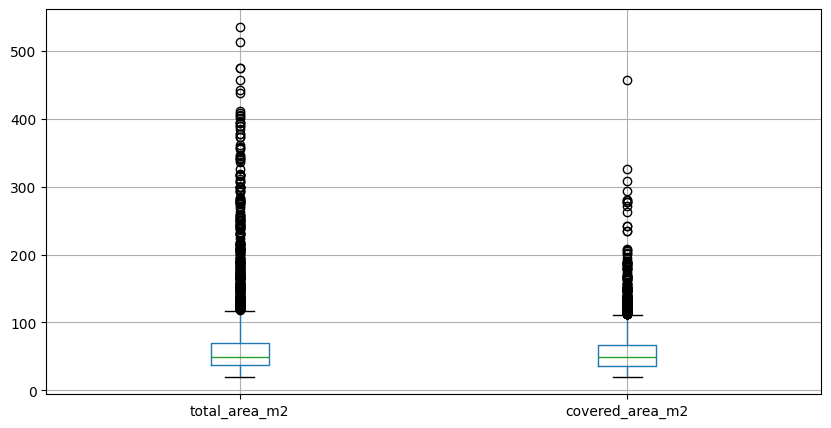

In [472]:
# Análisis de outliers en áreas
cols = [ "total_area_m2", "covered_area_m2"]

df[cols].boxplot(figsize=(10,5))
plt.show()

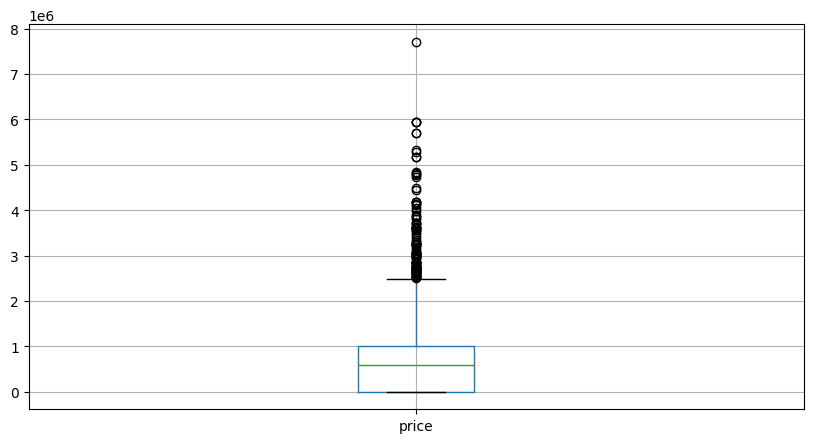

In [473]:
# Análisis de outliers en precio
cols = [ "price" ]

df[cols].boxplot(figsize=(10,5))
plt.show()

La distribución presenta una fuerte cola derecha con valores extremos que podrían corresponder tanto a propiedades atípicas como a errores de scraping. 
Habria que evaluar algunos puntos para ver si se deben a errores o a observaciones atípicas.

Opciones a evaluar a un futuro: 
- Conversiones (por ejemplo, logaritmica)
- Eliminar outliers más extremos



### Descarga de Dataset procesado

In [474]:
df.info()

<class 'pandas.DataFrame'>
Index: 4965 entries, 1 to 7300
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   source             4965 non-null   str    
 1   price              4965 non-null   float64
 2   total_area_m2      4965 non-null   float64
 3   covered_area_m2    4965 non-null   float64
 4   rooms              4965 non-null   float64
 5   bedrooms           4965 non-null   float64
 6   bathrooms          4965 non-null   float64
 7   property_type      4965 non-null   str    
 8   neighborhood       4965 non-null   str    
 9   lat                4965 non-null   float64
 10  lon                4965 non-null   float64
 11  bedrooms_missing   4965 non-null   int64  
 12  bathrooms_missing  4965 non-null   int64  
 13  rooms_missing      4965 non-null   int64  
dtypes: float64(8), int64(3), str(3)
memory usage: 676.9 KB


In [475]:
df.to_csv("../data/dataset_unificado.csv", index=False)